In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rebound
import astropy.constants as const
import os 
import time
import netCDF4
import glob
from astropy import units as u
from multiprocessing import Pool
import json
import re
from plotting_params import use_my_style
from rebound import hash as rebound_hash
use_my_style()

## 40 AU Check

In [2]:
files = glob.glob(f'core_results/tracks*check.nc')

def read_files(filenames, n_planets):

    filecount = 0

    params = ['ecc', 'a', 'inc']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    
    for index, file in enumerate(filenames):



        with netCDF4.Dataset(file, 'r') as ncfile:

            massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1, 4]
            massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1, 3]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))
            if n_planets == 3:
                c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 

            if c1 and c2:    
                filecount += 1

                for param, index in zip(params, [3,4,5]):
                    t0 = ncfile['test_particles'][0,:,index].compressed()
                    t1 = ncfile['test_particles'][-1, :, index].compressed()
                    all_data[param][0].extend(t0)
                    all_data[param][1].extend(t1)

    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    return all_data

In [3]:
all_data = read_files(filenames=files, n_planets=3)

for value in all_data['inc'][0]:
    if value < 0:
        print(value)

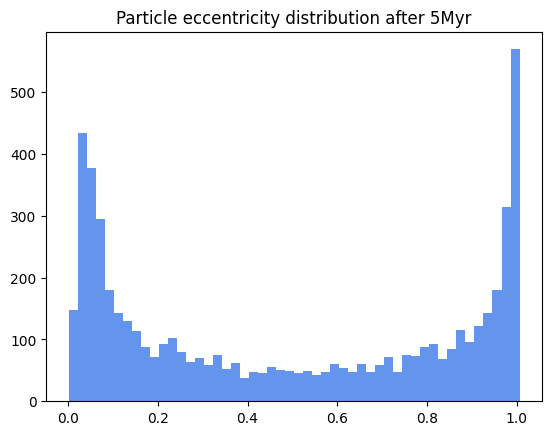

In [4]:
counts, _, _ = plt.hist(all_data['ecc'][1], bins=50, alpha=1,
                        label='t=5Myr',
                        color = 'cornflowerblue')
plt.title('Particle eccentricity distribution after 5Myr')
plt.show()

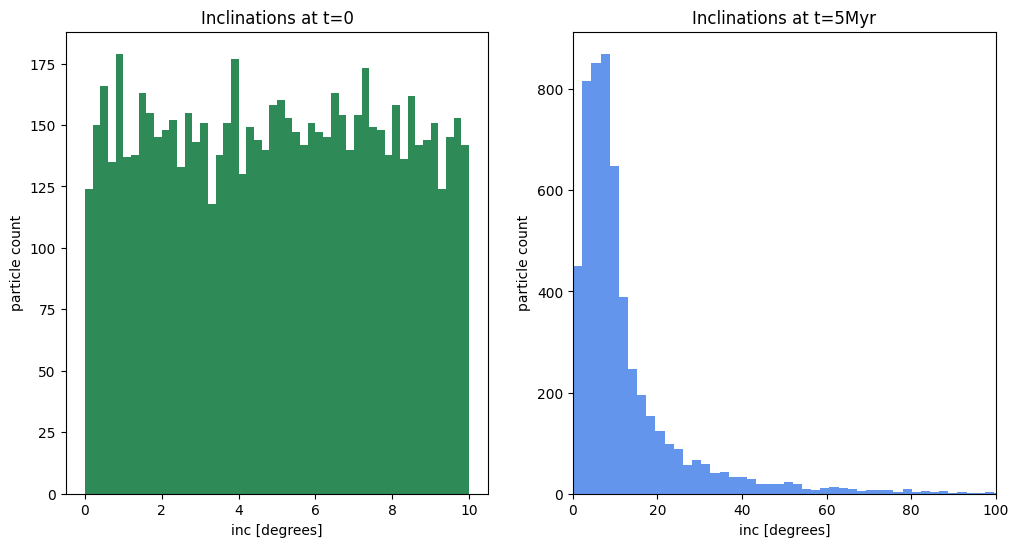

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].hist([np.degrees(i) for i in all_data['inc'][0]], bins=50, color='seagreen')
axes[0].set_title('Inclinations at t=0')
axes[1].hist([np.degrees(e) for e in all_data['inc'][1]], bins=80, color='cornflowerblue')
axes[1].set_title('Inclinations at t=5Myr')
axes[1].set_xlim(0, 100)

for i in [0,1]:
    axes[i].set_xlabel('inc [degrees]')
    axes[i].set_ylabel('particle count')

plt.show()

Why are there no inclinations below 0 if I set them up to be between -10 and 10??

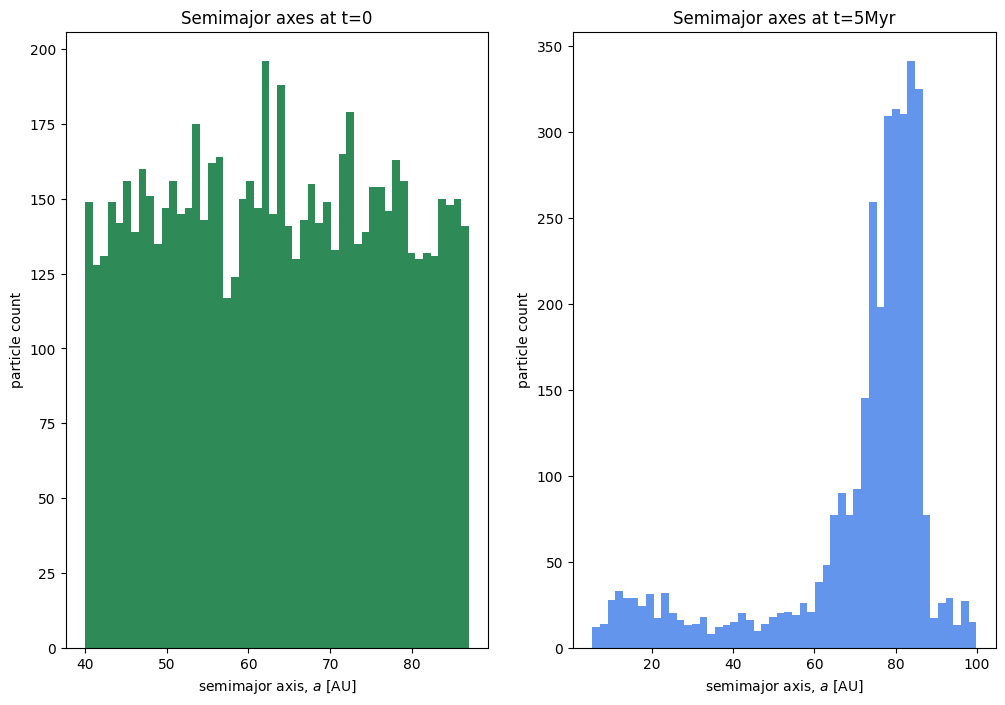

In [6]:
filtered_as = [x for x in all_data['a'][1] if (x <= 100 and x > 0)]

fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].hist(all_data['a'][0], bins=50, color='seagreen')
axes[0].set_title('Semimajor axes at t=0')
axes[1].hist(filtered_as, bins=50, color='cornflowerblue')
axes[1].set_title('Semimajor axes at t=5Myr')

for i in [0,1]:
    axes[i].set_xlabel(r'semimajor axis, $a$ [AU]')
    axes[i].set_ylabel('particle count')

plt.show()

## Dynamical timescale of PDS 70

In [2]:
import astropy.constants as const
import astropy.units as u
import numpy as np

R_star = 1.185830 * const.R_sun
G = const.G
M = const.M_sun * 0.640

t_dy = np.sqrt(R_star**3/(G*M))
t_dy.to('s')



<Quantity 2571.11114505 s>

## Branching ratios (aline paper files)

In [2]:
# files3pl = glob.glob(f'aline_paper/*keep*.nc')
# files2pl = glob.glob(f'aline_paper/two_planet_stuff/*Star.nc')

two_pl_files_new = glob.glob(f'core_outputs_yr2/*2_pl*saving*.nc')
three_pl_files_new = glob.glob(f'core_outputs_yr2/*3_pl_*saving_every_100_yrs.nc')

print(len(two_pl_files_new), len(three_pl_files_new))

def read_files(filenames, n_planets, newformat = True):
    '''
    Reads the netCDF files and extracts the relevant data for the test particles, as well as the migrated, ejected, collided and captured particles.
    It also checks if the planets are stable (eccentricity < 1 and no orbit crossing) and only includes the files that are stable.
    '''

    filecount = 0

    params = ['ecc', 'a', 'inc', 'hash']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    mig_data = {param: [] for param in ['time', 'hash']}
    
    ej_data = {param: [] for param in ['time', 'hash']}
    col_data = {param: [] for param in ['time', 'hash', 'planet']}
    capt_data = {param: [] for param in ['time', 'hash', 'planet']}

    for index, file in enumerate(filenames):

        with netCDF4.Dataset(file, 'r') as ncfile:

            ########### stability check ##############
            if newformat:
                massive_bodies_a = ncfile['test_particles'][-1, 0:n_planets, 5]
                massive_bodies_e = ncfile['test_particles'][-1, 0:n_planets, 4]

            else:
                if n_planets == 2:
                    massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,5]
                    massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,4]
                elif n_planets == 3:
                    massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,4]
                    massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,3]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))

            if not newformat:
                if n_planets == 3:
                    c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 
            if newformat:
                if n_planets == 3:
                    c2 = ((dist[0] < dist_small[1])) and (dist[1] < dist_small[2] ) 

    
            ############ if stable, add the file and the particles ############
            if c1 and c2:    
                filecount += 1

                paramlist = [4,5,6,-1] if newformat else [3,4,5,-1]

                for param, index in zip(params, paramlist):
                    t0 = ncfile['test_particles'][0, n_planets:,index].compressed()
                    t1 = ncfile['test_particles'][-1, n_planets:, index].compressed()
                    all_data[param][0].extend(t0)
                    all_data[param][1].extend(t1)
                
                time = ncfile['migrated_peri'][:, 0].compressed()
                particle = ncfile['migrated_peri'][:, -1].compressed()
                mig_data['time'].extend(time)
                mig_data['hash'].extend(particle)

                ej_time = ncfile['ejected'][:, 0].compressed()
                ej_particle = ncfile['ejected'][:, -1].compressed()
                ej_data['time'].extend(ej_time)
                ej_data['hash'].extend(ej_particle)

                col_time = ncfile['collided'][:,0].compressed()
                col_particle = ncfile['collided'][:,-2].compressed()
                col_data['time'].extend(col_time)
                col_data['hash'].extend(col_particle)
                col_data['planet'].extend(ncfile['collided'][:,-1].compressed())

                capt_time = ncfile['captured'][:,0].compressed()
                capt_particle = ncfile['captured'][:,-2].compressed()
                capt_data['time'].extend(capt_time)
                capt_data['hash'].extend(capt_particle)
                capt_data['planet'].extend(ncfile['captured'][:,-1].compressed())

    n_particles = 200*filecount
    print(n_particles, 'particles')
    print(len(mig_data['hash']),len(ej_data['hash']))
    print('collided and captured', len(capt_data['hash']), len(col_data['hash']))
    
    ####### turn everything into floats #########
    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    return all_data, mig_data, ej_data, col_data, capt_data, n_particles


50 50


In [3]:
read_files(filenames=two_pl_files_new, n_planets=2, newformat=True)[0]

10000 particles
1955 5001
collided and captured 0 0


{'ecc': {0: [0.014061386696994305,
   0.009533381089568138,
   0.02818044275045395,
   0.009743927046656609,
   0.018790647387504578,
   0.010425596497952938,
   0.030857356265187263,
   0.01076838281005621,
   0.01315904688090086,
   0.0136587955057621,
   0.007791520096361637,
   0.01033736765384674,
   0.01096948143094778,
   0.012330078519880772,
   0.007044149097055197,
   0.031037403270602226,
   0.025432532653212547,
   0.007733374834060669,
   0.007970458827912807,
   0.015846438705921173,
   0.0071959542110562325,
   0.015534737147390842,
   0.012932317331433296,
   0.030828312039375305,
   0.031008798629045486,
   0.015243700705468655,
   0.00999352429062128,
   0.013038253411650658,
   0.02931801974773407,
   0.01572495326399803,
   0.01578289084136486,
   0.010685162618756294,
   0.012374566867947578,
   0.015385936945676804,
   0.00679601076990366,
   0.006626361981034279,
   0.03047771006822586,
   0.014701008796691895,
   0.018781492486596107,
   0.013806059025228024,
  

10000 particles
1955 5001
collided and captured 0 0


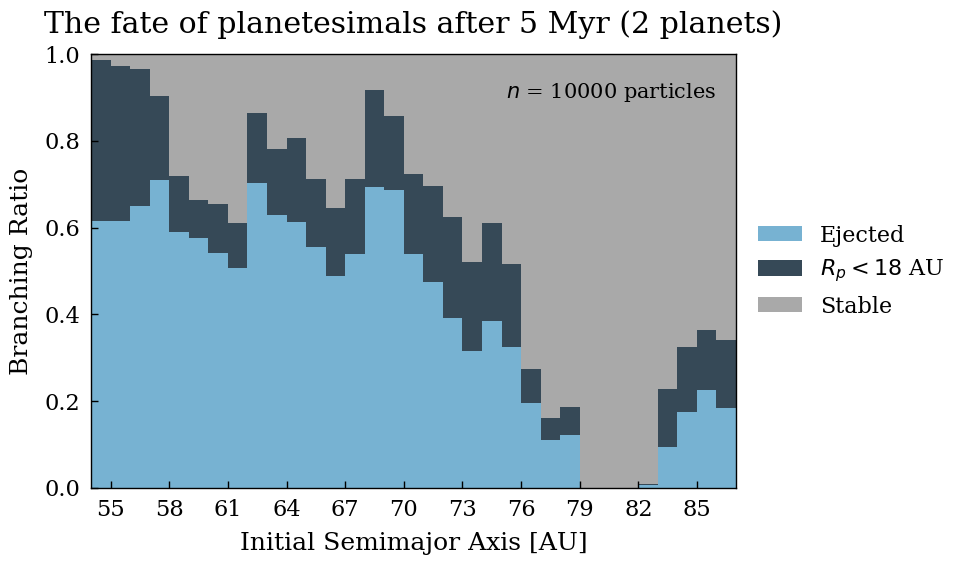

8200 particles
1180 1721
collided and captured 0 0


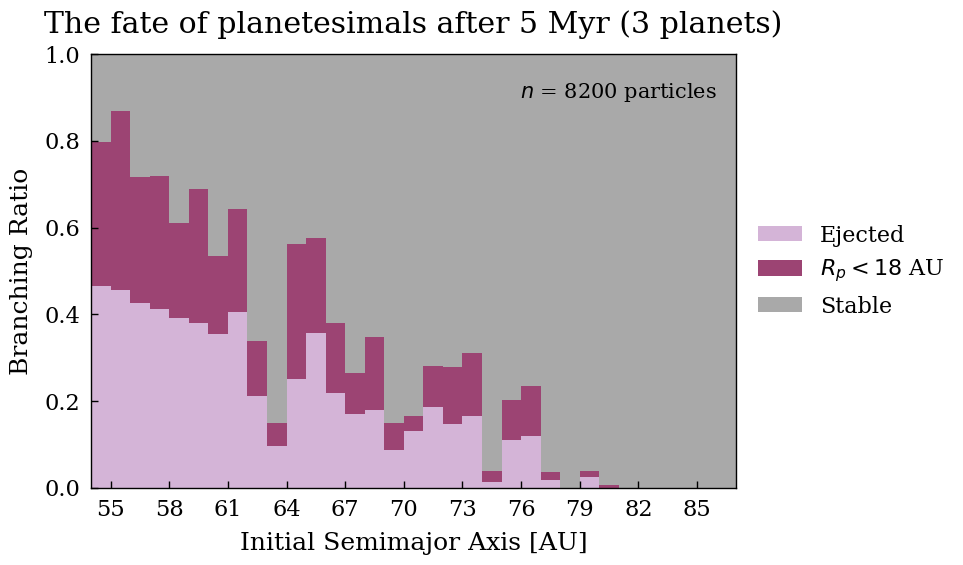

{'time': [2623588.75,
  2809971.75,
  3141507.75,
  3716821.25,
  4065683.5,
  4079633.75,
  4310657.0,
  4458830.0,
  4936949.5,
  1391015.875,
  1409818.0,
  1410225.875,
  1420546.875,
  1429756.25,
  1478306.625,
  1512131.25,
  1518223.25,
  1522071.875,
  1533843.875,
  1581938.25,
  1582041.25,
  1584068.125,
  1587612.25,
  1602484.875,
  1653614.625,
  1665170.5,
  1682974.25,
  1723171.5,
  1752709.875,
  1785342.25,
  1864501.625,
  1878471.625,
  1924221.25,
  1931862.125,
  1933519.5,
  1995761.875,
  2025474.5,
  2145144.25,
  2299898.0,
  2360940.5,
  2375966.25,
  2427049.0,
  2445277.0,
  2455990.0,
  2539949.0,
  2550605.0,
  2557104.25,
  2585052.0,
  2594649.25,
  2612182.0,
  2637546.25,
  2641893.5,
  2752069.5,
  2757549.5,
  2781336.5,
  2789449.75,
  2805145.0,
  2968281.5,
  2981980.0,
  3000738.0,
  3057169.0,
  3125581.75,
  3213221.75,
  3241046.5,
  3403449.0,
  3405105.75,
  3506429.0,
  3517709.25,
  3524929.25,
  3656923.75,
  3765399.5,
  3779702.25,
 

In [4]:
from plotting_params import use_my_style
use_my_style()

def plot(filename, n_planets, plot=True):
    loaded_data = read_files(filenames=filename, n_planets=n_planets)
    all_data = loaded_data[0]
    mig_data = loaded_data[1]
    ej_data = loaded_data[2]
    col_data = loaded_data[3]
    capt_data = loaded_data[4]
    n_particles = loaded_data[-1]

    mig_dict = {k: [float(x) for x in v] for k, v in mig_data.items()}
    ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
    col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
    capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}  

    # add new column to each dict for the initial semimajor axis of the particles  
    mig_dict['initial_a'] = [0] * len(mig_dict['hash'])
    ej_dict['initial_a'] = [0] * len(ej_dict['hash'])
    col_dict['initial_a'] = [0] * len(col_dict['hash'])
    capt_dict['initial_a'] = [0] * len(capt_dict['hash'])

    ########## for each category (mig, ej, capt, col), get init semimajor axis from the all_data dict using the hash as index ############
    for i, hash in enumerate(mig_dict['hash']):
        index = all_data['hash'][0].index(hash)
        initial_semimajoraxis = all_data['a'][0][index]
        mig_dict['initial_a'][i] = initial_semimajoraxis

    for i, hash in enumerate(ej_dict['hash']):
        index_ej = all_data['hash'][0].index(hash)
        initial_semimajoraxis_ej = all_data['a'][0][index_ej]
        ej_dict['initial_a'][i] = initial_semimajoraxis_ej
    
    for i, hash in enumerate(col_dict['hash']):
        index_col = all_data['hash'][0].index(hash)
        initial_semimajoraxis_col = all_data['a'][0][index_col]
        col_dict['initial_a'][i] = initial_semimajoraxis_col
    
    for i, hash in enumerate(capt_dict['hash']):
        index_capt = all_data['hash'][0].index(hash)
        initial_semimajoraxis_capt = all_data['a'][0][index_capt]
        capt_dict['initial_a'][i] = initial_semimajoraxis_capt


    ############ get the initial semimajor axis and hash for all stable particles ############
    ej_hashes = np.array(ej_dict['hash'])
    mig_hashes = np.array(mig_dict['hash'])
    col_hashes = np.array(col_dict['hash'])
    capt_hashes = np.array(capt_dict['hash'])

    all_bad_hashes = np.concatenate((ej_hashes, mig_hashes, col_hashes, capt_hashes))
    hash_new, a_new = zip(*[(hashval, aval) for hashval, aval in zip(all_data['hash'][0], all_data['a'][0]) if hashval not in all_bad_hashes])

    ############## start plotting #################
    if plot:
        fig, ax = plt.subplots(figsize=(10,6))
        bins = np.linspace(54, 87, 34)
        ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
        migrated_counts, _ = np.histogram(mig_dict['initial_a'], bins=bins)
        col_counts, _ = np.histogram(col_dict['initial_a'], bins=bins)
        capt_counts, _ = np.histogram(capt_dict['initial_a'], bins=bins)

        all_others, _ = np.histogram(a_new, bins=bins)

        stacked_counts = np.vstack([all_others, ejected_counts, migrated_counts, col_counts, capt_counts])

        bin_sums = stacked_counts.sum(axis=0)
        x = bins[:-1]
        width = 1
        stacked_counts = stacked_counts / bin_sums
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        if n_planets == 3:
            color1 = "#841550FF" # darker purple
            color2 = "#CAA1CD" # "#CAA1CD"
            color3 = 'orange'
            color4 = 'purple'
        elif n_planets == 2:
            color2= "#559fc7",  # medium
            color1 = "#031c2d",  # dark
            color3 = 'blue'
            color4 = 'orange'

        plt.bar(x, stacked_counts[1], width=1,
                alpha=0.8, label="Ejected", color=color2, align='edge')

        plt.bar(x, stacked_counts[2], width=1, bottom=stacked_counts[1],
                alpha=0.8, label=r"$R_p < 18$ AU", color=color1, align='edge')

        plt.bar(x, stacked_counts[0], width=1,
                bottom=stacked_counts[2]+stacked_counts[1]+stacked_counts[3]+stacked_counts[4],
                alpha=1, label="Stable", color="darkgrey", align='edge')

        plt.minorticks_off()
        tick_idx = np.arange(1, len(bins), 3)

        ax.set_xticks(bins[tick_idx])
        ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

        plt.text(86, 0.9, rf'$n$ = {n_particles} particles', color='k', ha='right', fontsize=15)
        plt.xlabel('Initial Semimajor Axis [AU]')
        plt.ylabel('Branching Ratio')
        plt.title(f'The fate of planetesimals after 5 Myr ({n_planets} planets)', y=1.03)
        plt.xlim(54, 87)
        ax.legend(
            loc='center left',        # align vertically centered to axes
            bbox_to_anchor=(1.02, 0.5),  # x=1.02 → just outside, y=0.5 → center vertically
            borderaxespad=0,          # padding between axes and legend
            frameon=False,
            fontsize=16             # optional: remove legend box
        )
        plt.tight_layout()
        plt.show()
        #plt.savefig(f'plots/branching_ratio_{n_planets}_pl_simple_with_captures.png')

    # return mig_dict for gas drag analysis later
    return mig_dict

plot(two_pl_files_new, 2)
plot(three_pl_files_new, 3)

In [ ]:

print(rebound_hash('pb').value)
#c_uint(7444021), c_uint(8627021)

#2008711773


2008711773


## Gas drag files need a different processing

In [5]:
def read_gas_drag_files(filenames, n_planets):

    filecount = 0

    params = ['ecc', 'initial_a', 'inc', 'hash']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    star_grazed_data = {param: [] for param in ['time', 'hash']}
    
    ej_data = {param: [] for param in ['time', 'hash',]}
    col_data = {param: [] for param in ['time', 'hash', 'planet']}
    capt_data = {param: [] for param in ['time', 'hash', 'planet']}

    for index, file in enumerate(filenames):

        with netCDF4.Dataset(file, 'r') as ncfile:

            massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,5]
            massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,4]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))

            elif n_planets == 3:
                c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 

            #if stable, add the file and the particles
            if c1 and c2:    
                filecount += 1

                paramlist = [4,5,6,-1]

                for parameter, index in zip(params, paramlist):
                    t0 = ncfile['test_particles'][0, index].compressed()
                    
                    t1 = ncfile['test_particles'][-1, index].compressed()
                    all_data[parameter][0].extend(t0)
                    all_data[parameter][1].extend(t1)

                if 'star_grazed' in ncfile.variables:
                    star_grazed_data['time'].extend(ncfile['star_grazed'][:, 0].compressed())
                    star_grazed_data['hash'].extend(ncfile['star_grazed'][:, -1].compressed())
    
                ej_data['time'].extend(ncfile['ejected'][:, 0].compressed())
                ej_data['hash'].extend(ncfile['ejected'][:, -1].compressed())

                col_data['time'].extend(ncfile['collided'][:,0].compressed())
                col_data['hash'].extend(ncfile['collided'][:,-2].compressed())
                col_data['planet'].extend(ncfile['collided'][:,-1].compressed())

                capt_data['time'].extend(ncfile['captured'][:,0].compressed())
                capt_data['hash'].extend(ncfile['captured'][:,-2].compressed())
                capt_data['planet'].extend(ncfile['captured'][:,-1].compressed())


    n_particles = 1*filecount
    print(n_particles, 'particles')
    print(len(star_grazed_data['hash']),
    len(ej_data['hash']))
    print('collided and captured', len(capt_data['hash']), len(col_data['hash']))
    print(capt_data['planet'])
    print(len(all_data['ecc'][0]) - len(all_data['ecc'][1]))
    
    #convert to floats
    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    #print(all_data)

    return all_data, ej_data, col_data, capt_data, star_grazed_data, n_particles

In [6]:
gas_drag_2_pl = glob.glob(f'core_outputs_yr2/gas_drag/*2_pl_single_particle_new.nc')

# def get_core_number(filename):
#     base = os.path.basename(filename)
#     m = re.search(r'core_(\d+)_', base)
#     return int(m.group(1)) if m else -1

# sorted_with_gas = sorted(gas_drag_2_pl, key=get_core_number)

two_planet_all_files = read_gas_drag_files(filenames=gas_drag_2_pl, n_planets=2)

1944 particles
56 1380
collided and captured 141 65
[np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np

In [7]:
gas_drag_three_pl = glob.glob('core_outputs_yr2/gas_drag/*3_pl_single_particle_new.nc')
three_planet_all_files = read_gas_drag_files(filenames=gas_drag_three_pl, n_planets=3)

1129 particles
56 466
collided and captured 0 20
[]
542


In [8]:
three_pl_no_gd =  glob.glob('core_outputs_yr2/gas_drag/*3_pl_single_particle_new_NOGD.nc')
three_pl_no_gd_all_files = read_gas_drag_files(filenames=three_pl_no_gd, n_planets=3)

two_pl_no_gd = glob.glob('core_outputs_yr2/gas_drag/*2_pl_single_particle_new_NOGD.nc')
two_pl_no_gd_all_files = read_gas_drag_files(filenames=two_pl_no_gd, n_planets=2)

1136 particles
41 449
collided and captured 0 23
[]
513
1943 particles
51 1386
collided and captured 152 53
[np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), np.float32(1.6765257e+09), 

10000 particles
1955 5001
collided and captured 0 0
2008711773 1676525745 3868333924 3376927956
[397 154 125 189 225 195 269 103  21  40]


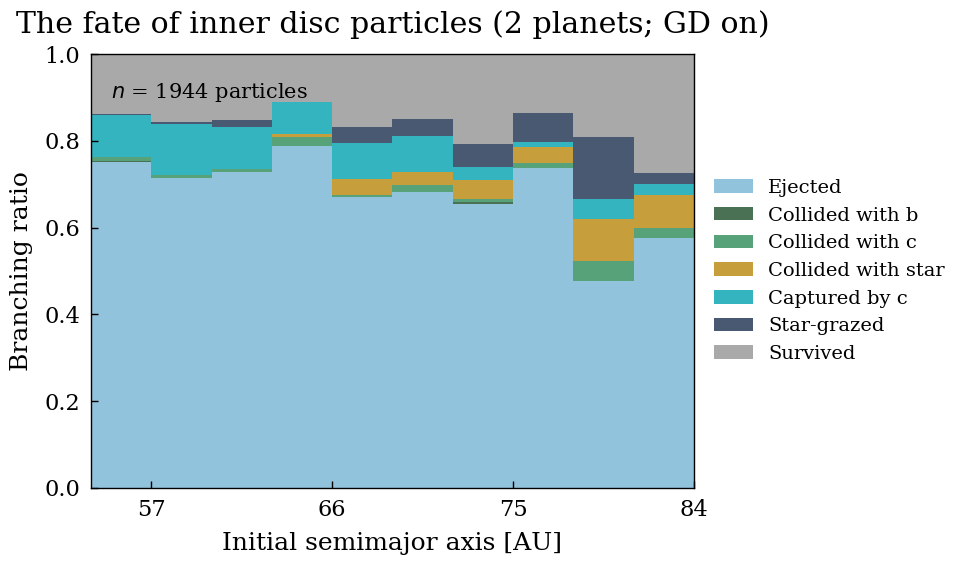

8200 particles
1180 1721
collided and captured 0 0
2008711773 1676525745 3868333924 3376927956
[305 281 172  51 143  65  62  61   7   0]


/tmp/ipykernel_705106/3786311423.py:117: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


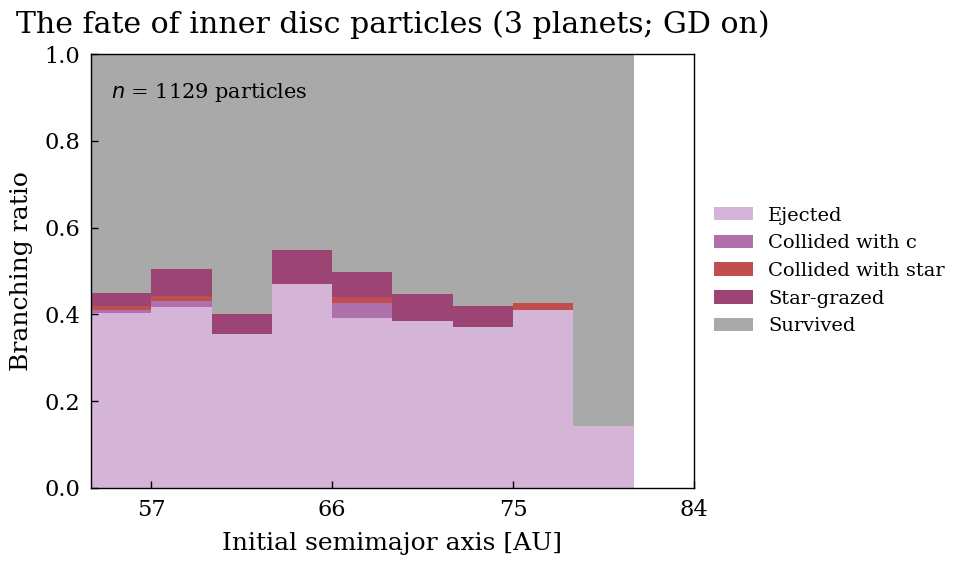

In [10]:
def plot_gd(combined_files, original_file, n_planets):
    all_data = plot(original_file, n_planets, plot=False)

    ej_data = combined_files[1]
    col_data = combined_files[2]
    capt_data = combined_files[3]
    grazed_data = combined_files[4]

    n_particles = combined_files[-1]

    ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
    col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
    capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}    
    grazed_dict = {k: [float(x) for x in v] for k, v in grazed_data.items()}

    ej_hashes = np.array(ej_dict['hash'])
    col_hashes = np.array(col_dict['hash'])
    capt_hashes = np.array(capt_dict['hash'])
    grazed_hashes = np.array(grazed_dict['hash'])

    all_bad_hashes = np.concatenate((ej_hashes, col_hashes, capt_hashes, grazed_hashes))

    hash_new, a_new = zip(*[(hashval, aval) for hashval, aval in zip(all_data['hash'], all_data['initial_a']) if hashval not in all_bad_hashes])
    
    ej_dict['initial_a'] = [0] * len(ej_dict['hash'])
    col_dict['initial_a'] = [0] * len(col_dict['hash'])
    capt_dict['initial_a'] = [0] * len(capt_dict['hash'])
    grazed_dict['initial_a'] = [0] * len(grazed_dict['hash'])

    for i, hash in enumerate(ej_dict['hash']):
        index_ej = all_data['hash'].index(int(hash))
        initial_semimajoraxis_ej = all_data['initial_a'][index_ej]
        ej_dict['initial_a'][i] = initial_semimajoraxis_ej
    
    for i, hash in enumerate(col_dict['hash']):
        index_col = all_data['hash'].index(int(hash))
        initial_semimajoraxis_col = all_data['initial_a'][index_col]
        col_dict['initial_a'][i] = initial_semimajoraxis_col
    
    for i, hash in enumerate(capt_dict['hash']):
        index_capt = all_data['hash'].index(int(hash))
        initial_semimajoraxis_capt = all_data['initial_a'][index_capt]
        capt_dict['initial_a'][i] = initial_semimajoraxis_capt

    for i, hash in enumerate(grazed_dict['hash']):
        index_grazed = all_data['hash'].index(int(hash))
        initial_semimajoraxis_grazed = all_data['initial_a'][index_grazed]
        grazed_dict['initial_a'][i] = initial_semimajoraxis_grazed
    
    # Get planet hashes
    pb = rebound_hash('pb').value
    pc = rebound_hash('pc').value
    pd = rebound_hash('pd').value
    star = rebound_hash('star').value

    print(pb, pc, pd, star)

    # Separate by target
    collided_with = {'b': [], 'c': [], 'd': [], 'star': []}
    captured_by = {'b': [], 'c': [], 'd': []}

    # Separate collisions
    for i, planet_hash in enumerate(col_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            collided_with['b'].append(col_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            collided_with['c'].append(col_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            collided_with['d'].append(col_dict['initial_a'][i])
        elif abs(target - star) < 1000:
            collided_with['star'].append(col_dict['initial_a'][i])

    # Separate captures
    for i, planet_hash in enumerate(capt_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            captured_by['b'].append(capt_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            captured_by['c'].append(capt_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            captured_by['d'].append(capt_dict['initial_a'][i])
    
    fig, ax = plt.subplots(figsize=(10,6))

    spacing = 3
    bins = np.arange(54, 87, spacing)

    bin_widths = np.diff(bins)
    x = bins[:-1]

    # Create histograms for each category
    ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
    col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
    col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
    col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)
    col_star_counts, _ = np.histogram(collided_with['star'], bins=bins)
    capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
    capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
    capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)
    grazed_counts, _ = np.histogram(grazed_dict['initial_a'], bins=bins)
    all_others, _ = np.histogram(a_new, bins=bins)

    # Stack in desired order (adjust based on how you want to display)
    if n_planets==3:
        stacked_counts = np.vstack([all_others, ejected_counts, 
                                    col_b_counts, col_c_counts, col_d_counts, col_star_counts,
                                    capt_b_counts, capt_c_counts, capt_d_counts,
                                    grazed_counts])
    elif n_planets==2:
        stacked_counts = np.vstack([all_others, ejected_counts, 
                                    col_b_counts, col_c_counts, col_star_counts,
                                    capt_b_counts, capt_c_counts,
                                    grazed_counts])
    bin_sums = stacked_counts.sum(axis=0)
    print(bin_sums)
    stacked_counts = stacked_counts / bin_sums

    # Color scheme based on n_planets
    if n_planets == 3:
        colors = {
            'ejected': "#CAA1CD",  # kept same light purple
            'col_b': '#6a0dad',     # deep purple
            'col_c': '#9b4d96',     # medium purple-magenta
            'col_d': '#d46b9e',     # rose pink
            'col_star': '#b22222',  # firebrick red (distinct from purples)
            'capt_b': '#4a72b0',    # medium blue
            'capt_c': '#2a9d8f',    # teal
            'capt_d': '#56b4e9',    # sky blue
            'grazed': '#841550FF',  # kept same deep pinkish-purple
            'survived': 'darkgrey'  # kept same
        }
    elif n_planets == 2:
            colors = {
        'ejected': "#77b4d4",    # kept same medium blue
        'col_b': '#1e4d2b',       # deep forest green
        'col_c': '#2e8b57',       # sea green
        'col_star': '#b8860b',    # dark goldenrod (distinct from greens)
        'capt_b': '#0f52ba',      # sapphire blue
        'capt_c': '#00a1b0',      # vibrant cyan-teal
        'grazed': '#1a2f4e',      # navy blue (darker, distinct)
        'survived': 'darkgrey'    # kept same
    }

    # Plot with cumulative bottom
    bottom = np.zeros(len(x))
    
    # Plot in your desired order
    if n_planets == 3:
        # Ejected
        if np.nansum(stacked_counts[1]) > 0:
            plt.bar(x, stacked_counts[1], width=bin_widths, bottom=bottom,
                    alpha=0.8, label="Ejected", color=colors['ejected'], align='edge')
            bottom += stacked_counts[1]
        
        # Collisions with b, c, d, star
        for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), 
                                                 ('Collided with d', 4), ('Collided with star', 5)]):
            if np.nansum(stacked_counts[count_idx]) > 0:
                plt.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                        alpha=0.8, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge')
                bottom += stacked_counts[count_idx]
        
        # Captures by b, c, d
        for i, (label, count_idx) in enumerate([('Captured by b', 6), ('Captured by c', 7), ('Captured by d', 8)]):
            if np.nansum(stacked_counts[count_idx]) > 0:
                plt.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                        alpha=0.8, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge')
                bottom += stacked_counts[count_idx]
        
        # Star-grazed
        if np.nansum(stacked_counts[9]) > 0:
            plt.bar(x, stacked_counts[9], width=bin_widths, bottom=bottom,
                    alpha=0.8, label='Star-grazed', color=colors['grazed'], align='edge')
            bottom += stacked_counts[9]
    
    elif n_planets == 2:
        # Similar structure for 2 planets...
        # Ejected
        if np.nansum(stacked_counts[1]) > 0:
            plt.bar(x, stacked_counts[1], width=bin_widths, bottom=bottom,
                    alpha=0.8, label="Ejected", color=colors['ejected'], align='edge')
            bottom += stacked_counts[1]
        
        # Collisions with b, c, star
        for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), ('Collided with star', 4)]):
            if np.nansum(stacked_counts[count_idx]) > 0:
                plt.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                        alpha=0.8, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge')
                bottom += stacked_counts[count_idx]
        
        # Captures by b, c
        for i, (label, count_idx) in enumerate([('Captured by b', 5), ('Captured by c', 6)]):
            if np.nansum(stacked_counts[count_idx]) > 0:
                plt.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                        alpha=0.8, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge')
                bottom += stacked_counts[count_idx]
        
        # Star-grazed
        if np.nansum(stacked_counts[7]) > 0:
            plt.bar(x, stacked_counts[7], width=bin_widths, bottom=bottom,
                    alpha=0.8, label='Star-grazed', color=colors['grazed'], align='edge')
            bottom += stacked_counts[7]

    # Survived
    if np.nansum(stacked_counts[0]) > 0:
        plt.bar(x, stacked_counts[0], width=bin_widths, bottom=bottom,
                alpha=1, label="Survived", color=colors['survived'], align='edge')

    # Rest of the plotting code (axes, labels, legend, etc.) remains the same
    plt.minorticks_off()
    tick_idx = np.arange(1, len(bins), spacing)

    ax.set_xticks(bins[tick_idx])
    ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

    plt.text(55, 0.9, rf'$n$ = {n_particles} particles', color='k', ha='left', fontsize=15)
    plt.xlabel('Initial semimajor axis [AU]')
    plt.ylabel('Branching ratio')
    plt.title(f'The fate of inner disc particles ({n_planets} planets; GD on)', y=1.03)
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
        frameon=False,
        fontsize=14  # Slightly smaller due to more legend items
    )
    plt.tight_layout()
    plt.show()

plot_gd(two_planet_all_files, two_pl_files_new, 2)
plot_gd(three_planet_all_files, three_pl_files_new, 3)

In [ ]:
# def resonances(p,q, semimajor_axis):
#     return semimajor_axis * (p/q)**(2/3)

# list_of_res = [(2,1), (11,5), (12,5), (5,2), (8,3), (11,4)]
# res_w_b = [(9,2), (5,1), (11,2)] 

# distances_c = []
# distances_b = []

# for res in list_of_res:
#     distances_c.append(resonances(*res, 35.3))
# for resb in res_w_b:
#     distances_b.append(resonances(*resb, 21.1))
